## Codigo para Ensemble: mezclar predicciones de only_encoder

In [1]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Usa tqdm normal si ejecutas desde script .py, o tqdm.notebook si usas Jupyter
import chess
import chess.pgn
import joblib

# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [2]:
# Verificación de aceleración por GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# datos tomados del train
ELO_MIN = 1000 
ELO_MAX = 3390
ELO_MEAN = 2028.3
ELO_STD = 593.4
ELO_MEDIAN = 2028.0
ELO_Q1 = 1514.0
ELO_Q3 = 2538.0 
ELO_IQR = ELO_Q3 - ELO_Q1

In [5]:
def desnormalizar_elo(elo_norm, metodo):
    """Convierte el Elo normalizado de vuelta a puntos de Elo reales."""
    if metodo == "minmax":
        return elo_norm * (ELO_MAX - ELO_MIN) + ELO_MIN
    elif metodo == "standard":
        return elo_norm * ELO_STD + ELO_MEAN
    elif metodo == "robust":
        return elo_norm * ELO_IQR + ELO_MEDIAN
    else:
        return elo_norm

In [6]:
class ChessDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, norm_type="standard", return_ids=False):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        self.return_ids = return_ids

        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0], -1)
            
        self.X = X_filtrado

        self.game_idx = datos['game_idx']
        
        if norm_type == "minmax":
            y_seleccionada = datos['y_minmax']
        elif norm_type == "robust":
            y_seleccionada = datos['y_robust']
        elif norm_type == "raw":
            y_seleccionada = datos['y_raw']
        else:
            y_seleccionada = datos['y_standard'] # Por defecto
            
        # Lo pasamos a tensor y le damos forma (N, 1)
        self.y = torch.tensor(y_seleccionada, dtype=torch.float32).view(-1, 1)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        y_tensor = self.y[idx]
        
        if self.return_ids:
            idx_partida = self.game_idx[idx]
            return x_tensor, y_tensor, idx_partida
        else:
            return x_tensor, y_tensor

In [34]:
plies = [15,17,19,21,23,25,27] 
flatten = 1
norm = "standard" # "standard", "minmax", "robust"
crit = "huber" # "huber", "mse"
print("Cargando datasets a la memoria...")

test_ds = ChessDataset("../data/generado/only_enc/test_51.npz", plies_a_usar=plies, flatten=flatten, norm_type=norm, return_ids=True)

# El DataLoader se encarga de crear los batches y hacer el shuffle usando C++ internamente

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

Cargando datasets a la memoria...


In [35]:
y_true_list = []
with torch.no_grad():
    for _, batch_y, _ in test_loader:   
        y_true_list.extend(batch_y.numpy().flatten())

# --- 4. DESNORMALIZAR ---
y_true_real = desnormalizar_elo(np.array(y_true_list), norm)

In [36]:
predicciones_por_ply = []

for ply in plies:
    # Ruta del archivo .npz o de predicciones guardadas para este ply específico
    ruta_archivo = f"../data/predict/{crit}_{norm}_{ply}.npy"  # Ajusta según tu estructura
    datos = np.load(ruta_archivo)
    predicciones_por_ply.append(datos)
matriz_predicciones = np.array(predicciones_por_ply)
y_pred_promedio = np.mean(matriz_predicciones, axis=0)

errores_absolutos = np.abs(y_true_real - y_pred_promedio)
errores_cuadraticos = (y_true_real - y_pred_promedio) ** 2

mae = np.mean(errores_absolutos)
mediana_error = np.median(errores_absolutos)
rmse = np.sqrt(np.mean(errores_cuadraticos))
max_error = np.max(errores_absolutos)

print(f"Criterio: {crit}      Normalizacion {norm}     Ply: {plies}")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {mediana_error:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

Criterio: huber      Normalizacion standard     Ply: [15, 17, 19, 21, 23, 25, 27]
MAE (Error Absoluto Medio):   325.6 puntos de Elo
Mediana del Error:            278.7 puntos de Elo
RMSE (Raíz Error Cuadrático): 406.3 puntos de Elo
Peor equivocación del modelo: 1577.1 puntos de Elo


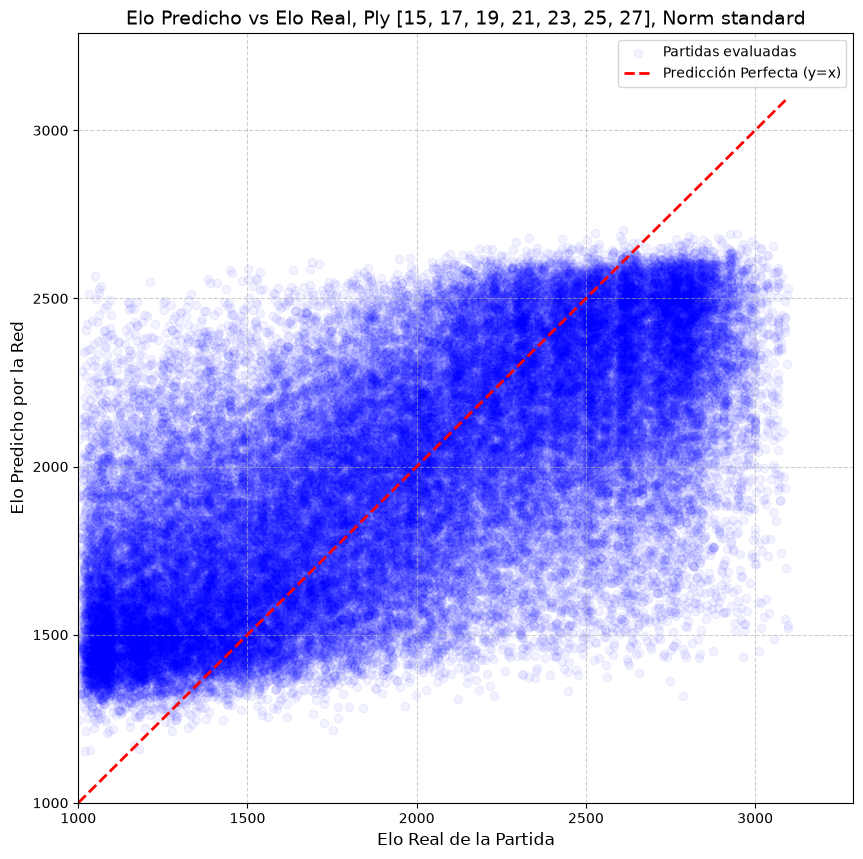

In [37]:
plt.figure(figsize=(10, 10))

plt.scatter(y_true_real, y_pred_promedio, alpha=0.05, color='blue', label='Partidas evaluadas')

min_val = min(min(y_true_real), min(y_pred_promedio))
max_val = max(max(y_true_real), max(y_pred_promedio))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Elo Predicho vs Elo Real, Ply {plies}, Norm {norm}', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()

In [38]:
from scipy.stats import linregress

# Asumiendo que losses_train y elos_train son arrays de numpy
slope, intercept, r_value, p_value, std_err = linregress(y_pred_promedio,y_true_real)

print(f"La ecuación es: real = {slope} * prediccion + {intercept}")
print(f"Correlación (R): {r_value:.4}") 

La ecuación es: real = 1.0551514625549316 * prediccion + -124.652099609375
Correlación (R): 0.6753


In [39]:

y_ajustado = slope * y_pred_promedio + intercept

errores_absolutos = np.abs(y_true_real - y_ajustado)
errores_cuadraticos = (y_true_real - y_ajustado) ** 2

mae = np.mean(errores_absolutos)
mediana_error = np.median(errores_absolutos)
rmse = np.sqrt(np.mean(errores_cuadraticos))
max_error = np.max(errores_absolutos)

print(f"Criterio: {crit}      Normalizacion {norm}     Ply: {ply}")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {mediana_error:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

Criterio: huber      Normalizacion standard     Ply: 27
MAE (Error Absoluto Medio):   322.5 puntos de Elo
Mediana del Error:            271.6 puntos de Elo
RMSE (Raíz Error Cuadrático): 405.5 puntos de Elo
Peor equivocación del modelo: 1618.0 puntos de Elo


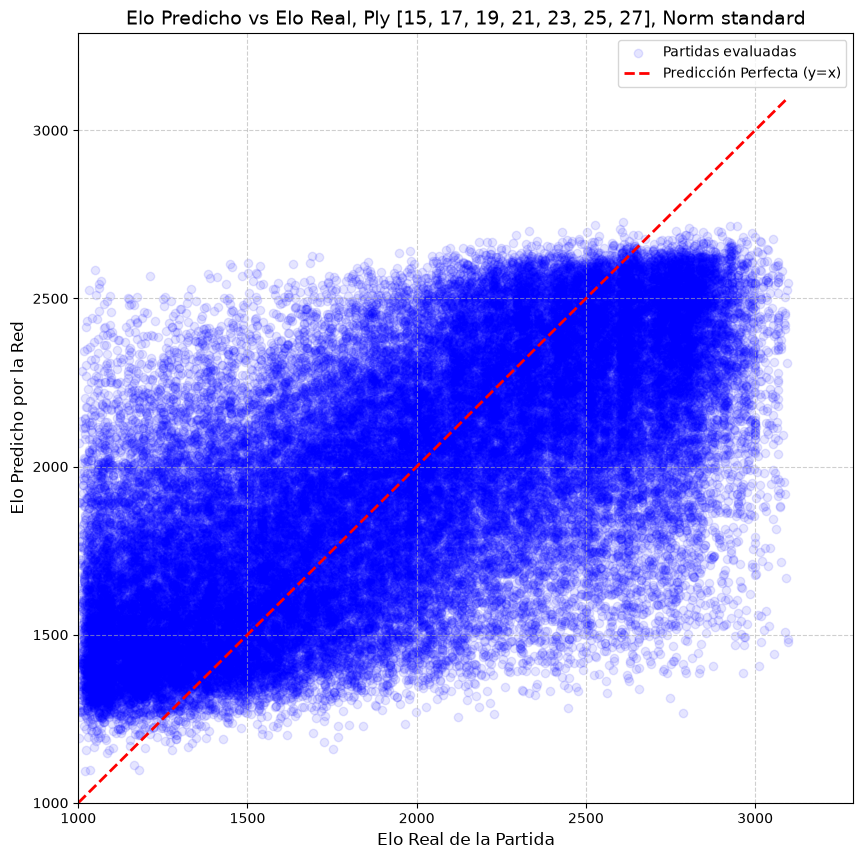

In [40]:
plt.figure(figsize=(10, 10))

plt.scatter(y_true_real, y_ajustado, alpha=0.1, color='blue', label='Partidas evaluadas')

min_val = min(min(y_true_real), min(y_ajustado))
max_val = max(max(y_true_real), max(y_ajustado))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Elo Predicho vs Elo Real, Ply {plies}, Norm {norm}', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()